In [1]:
# Import library dasar untuk pengolahan data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Import library untuk text processing
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

# Import library untuk data science (SMOTE, Split Data, & Model)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB

# (Catatan: Baris wordcloud di bagian paling bawah tadi duplikat, jadi sudah saya satukan di atas)


In [24]:
data = pd.read_csv("mobil_listrik.csv")
data.head()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
0,Ugzbll5eyrIy3-gdUUJ4AaABAg,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,UgzEDUiV3OTrV943p8p4AaABAg,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,UgwqJqu6JMF4EH2CsVV4AaABAg,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,UgyYicCMR1rKwuOj2Y14AaABAg,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,UgxKAcLuAwZOQK6es-x4AaABAg,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


## 1. Data Understanding

In [ ]:
#ngubah string jadi objek
for col in data.select_dtypes(include=['string']).columns:
    data[col] = data[col].astype(object)
data.dtypes

id_komentar      object
nama_akun        object
tanggal          object
text_cleaning    object
sentimen         object
dtype: object

In [28]:
data.shape

(1517, 5)

In [31]:
data = data.dropna()
data.isnull().sum()

id_komentar      0
nama_akun        0
tanggal          0
text_cleaning    0
sentimen         0
dtype: int64

In [32]:
data.duplicated().sum()

np.int64(0)

In [33]:
data.describe()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
count,1514,1514,1514,1514,1514
unique,1514,1513,1511,1513,3
top,Ugzbll5eyrIy3-gdUUJ4AaABAg,Albert,2023-06-06 15:19:27+00:00,mahal,negatif
freq,1,2,2,2,868


## 2. Prepocessing Text


In [34]:
data.head()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
0,Ugzbll5eyrIy3-gdUUJ4AaABAg,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,UgzEDUiV3OTrV943p8p4AaABAg,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,UgwqJqu6JMF4EH2CsVV4AaABAg,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,UgyYicCMR1rKwuOj2Y14AaABAg,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,UgxKAcLuAwZOQK6es-x4AaABAg,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


In [58]:
data_copy = data.copy()
data_copy = data.drop(columns="id_komentar")
data_copy.head()


,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kualitas buruk harga mahal croot,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat sembarangan woy anak muda belum pun...,negatif


In [62]:
data_copy["text_cleaning"]=data_copy["text_cleaning"].str.lower()
data_copy.head(20)

,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kualitas buruk harga mahal croot,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat sembarangan woy anak muda belum pun...,negatif
5,Syarif Airlangga,2023-08-04 06:58:17+00:00,harga motor mahal masa harga mirip motor beat ...,positif
6,BajuMax,2023-08-04 06:31:56+00:00,mol keren yah berita plus padahal mol loka...,negatif
7,Putut Parwoto,2023-08-04 01:04:18+00:00,proses kenal produk baru butuh waktu ganti ken...,negatif
8,Heru Prasetyo,2023-08-03 23:56:55+00:00,subsidi tepat sasar,netral
9,jonan kick ass hole,2023-08-03 11:25:57+00:00,adil rata terima subsidi jangan jangan pajak p...,negatif


In [64]:
# Normalisasi
norm = {"dgn":"dengan", "gue":"saya", "ngaco":"sembarangan", "kwalitas":"kualitas", "blom":"belum", "aing":"aku", "kudu":"harus"}

def normalisasi(str_text):
    for n in norm:
      str_text = str_text.replace(n, norm[n])
    return str_text  
data_copy["text_cleaning"] = data_copy["text_cleaning"].apply(lambda x: normalisasi(x))
data_copy.head()

,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kualitas buruk harga mahal croot,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat sembarangan woy anak muda belum pun...,negatif


In [89]:
#Stopword untuk menghilangkan kata kata yang tidak penting
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory,StopWordRemover,ArrayDictionary
more_stop_word =[]
stop_word=StopWordRemoverFactory().get_stop_words()
new_array = ArrayDictionary(stop_word)
stop_word_remover_new = StopWordRemover(new_array)

def stopwords(str_text):
  str_text= stop_word_remover_new.remove(str_text)
  return str_text
data_copy["text_cleaning"]=data_copy["text_cleaning"].apply(lambda x: stopwords(x))


In [90]:
#Tokenisasi
Tokenized = data_copy["text_cleaning"].apply(lambda x:x.split())
Tokenized


0       [saran, sih, bikin, harga, ionic, sama, kayak,...
1       [problem, subsidi, kualitas, diturunin, harga,...
2       [baik, kualitas, kembang, dulu, baik, kualitas...
3       [model, jelek, kualitas, buruk, harga, mahal, ...
4       [syarat, sembarang, woy, anak, muda, punya, ru...
                              ...                        
1509    [apa, kabar, padahal, negri, luar, biasa, negara]
1510    [antar, anak, sekolah, antar, bantu, pasar, kl...
1511                               [esemka, bangga, solo]
1512    [cerdas, orang, hny, dn, pasar, jln, x, da, gi...
1513    [niat, beli, ev, murah, malah, ikut, dinaikin,...
Name: text_cleaning, Length: 1514, dtype: object

In [96]:
#Stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
def stemming(text_cleaning):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do=[]
  for w in text_cleaning:
    dt=stemmer.stem (w)
    do.append(dt)
  d_clean =[]
  d_clean = " ".join (do)
  print(d_clean)
  return d_clean
Tokenized=Tokenized.apply(stemming)
Tokenized.to_csv("mobil_listrik_bersih.csv",index=False)
data_clean = pd.read_csv("mobil_listrik_bersih.csv",encoding="latin1")
data_clean.head()
    
  

saran sih bikin harga ionic sama kayak brio insya alloh laris manis
problem subsidi kualitas diturunin harga dinaikin usaha gitu cari cuan subsidi inflasi paling gede
baik kualitas kembang dulu baik kualitas motor motor pabrikan jepang
model jelek kualitas buruk harga mahal croot
syarat sembarang woy anak muda punya rumah jd umkm bukan kur dapet sembarang sia deui sia deui nu narima subsidi teh ari aku iraha
harga motor mahal masa harga mirip motor beat kualitas bagai langit bumi
mol keren yah berita plus padahal mol lokal merk batrenya juta garansi tahun anggap batre awet tahun rakyat indonesia per tahun sekali keluar juta buat beli batre baru o saran uang subsidi keluar buat batre perintah punya wewenang pertamina kelola contoh gas kg gas kg gas kg produk baru misal batre v batre v batre v cabut bayar pasang gas pnp pom sistem swap batre banyak titik swap point indonesia luas
proses kenal produk baru butuh waktu ganti kendara bbm jadi kendara butuh waktu tehnologi baru sabar
subsidi 

,text_cleaning
0,saran sih bikin harga ionic sama kayak brio in...
1,problem subsidi kualitas diturunin harga dinai...
2,baik kualitas kembang dulu baik kualitas motor...
3,model jelek kualitas buruk harga mahal croot
4,syarat sembarang woy anak muda punya rumah jd ...


In [ ]:
at1=pd.read_csv("mobil_listrik_bersih.csv")
at2=pd.read_csv("mobil_listrik.csv")
att2=at2["sentimen"]
data_clean=pd.concat([at1,att2],axis=1)

data_clean



,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,positif
1,problem subsidi kualitas diturunin harga dinai...,negatif
2,baik kualitas kembang dulu baik kualitas motor...,positif
3,model jelek kualitas buruk harga mahal croot,negatif
4,syarat sembarang woy anak muda punya rumah jd ...,negatif
...,...,...
1512,cerdas orang hny dn pasar jln x da gimana kota...,negatif
1513,niat beli ev murah malah ikut dinaikin sama pe...,negatif
1514,NaN,positif
1515,NaN,netral


In [100]:
data_clean=data_clean.dropna()
data_clean

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,positif
1,problem subsidi kualitas diturunin harga dinai...,negatif
2,baik kualitas kembang dulu baik kualitas motor...,positif
3,model jelek kualitas buruk harga mahal croot,negatif
4,syarat sembarang woy anak muda punya rumah jd ...,negatif
...,...,...
1509,apa kabar padahal negri luar biasa negara,negatif
1510,antar anak sekolah antar bantu pasar klw jauh ...,positif
1511,esemka bangga solo,positif
1512,cerdas orang hny dn pasar jln x da gimana kota...,negatif


In [104]:
data_clean = data_clean[data_clean["sentimen"]!="netral"]
data_clean.head(20)

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,positif
1,problem subsidi kualitas diturunin harga dinai...,negatif
2,baik kualitas kembang dulu baik kualitas motor...,positif
3,model jelek kualitas buruk harga mahal croot,negatif
4,syarat sembarang woy anak muda punya rumah jd ...,negatif
5,harga motor mahal masa harga mirip motor beat ...,positif
6,mol keren yah berita plus padahal mol lokal me...,negatif
7,proses kenal produk baru butuh waktu ganti ken...,negatif
9,adil rata terima subsidi jangan jangan pajak p...,negatif
10,tepat sasar donk syarat tepat subsidi kurang b...,negatif


In [106]:
data_clean=data_clean.replace({"positif":1,"negatif":0})
data_clean.head()

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,1
1,problem subsidi kualitas diturunin harga dinai...,0
2,baik kualitas kembang dulu baik kualitas motor...,1
3,model jelek kualitas buruk harga mahal croot,0
4,syarat sembarang woy anak muda punya rumah jd ...,0


## 3. Visualisasi Data

In [108]:
data_negatif=data_clean[data_clean["sentimen"]==0]
data_positif=data_clean[data_clean["sentimen"]==1]

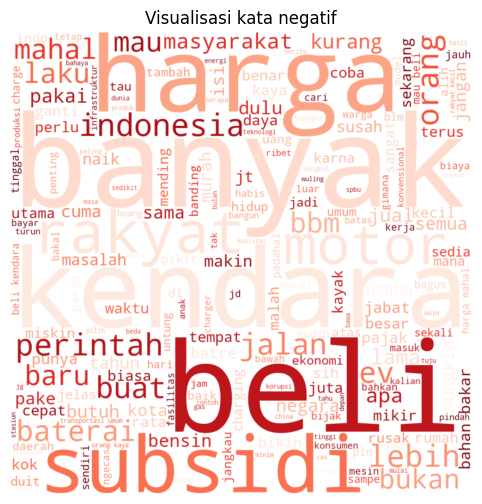

In [117]:
all_text_s0=" ".join(word for word in data_negatif["text_cleaning"])
wordcloud=WordCloud(colormap="Reds",width=1000,height=1000,mode="RGBA",background_color="white").generate(all_text_s0)
plt.figure(figsize=(10,6  ))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Visualisasi kata negatif")
plt.margins(x=0,y=0)
plt.show()

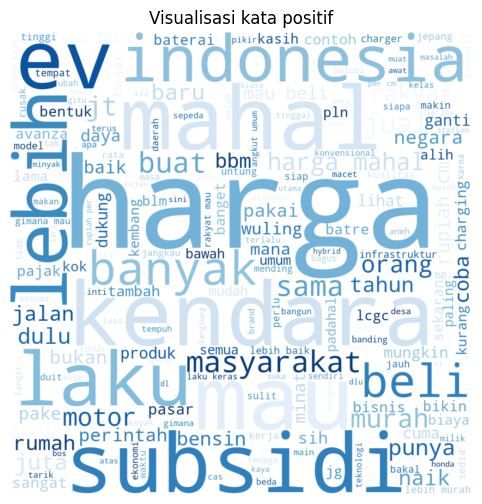

In [118]:
all_text_s1=" ".join(word for word in data_positif["text_cleaning"])
wordcloud=WordCloud(colormap="Blues",width=1000,height=1000,mode="RGBA",background_color="white").generate(all_text_s1)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Visualisasi kata positif")
plt.margins(x=0,y=0)
plt.show()

In [125]:
data_clean["sentimen"].value_counts()
data_clean.dtypes

text_cleaning       str
sentimen         object
dtype: object

C:\Users\HP\AppData\Local\Temp\ipykernel_19692\945086421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_clean,x="sentimen",palette={"0":"red","1":"lightskyblue"})


<function matplotlib.pyplot.show(close=None, block=None)>

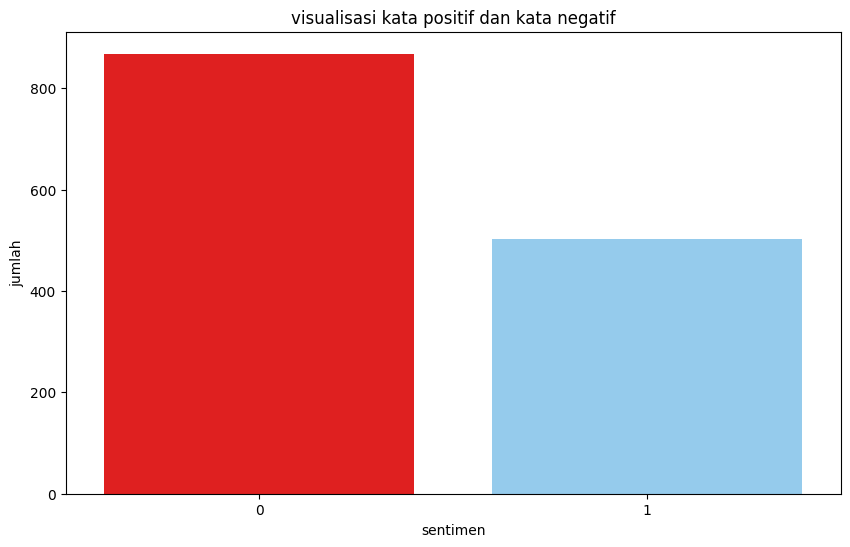

In [126]:
# visualisasi sentimen positif dan negatif
plt.figure(figsize=(10,6))
sns.countplot(data=data_clean,x="sentimen",palette={"0":"red","1":"lightskyblue"})
plt.title("visualisasi kata positif dan kata negatif")
plt.xlabel("sentimen")
plt.ylabel("jumlah")
plt.show

## 4. Data Preparation

In [161]:
x= data_clean["text_cleaning"]
y=data_clean["sentimen"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)
x_train.isnull().sum()

np.int64(0)

In [165]:
##mengubah teks menjadi fitur numerik
vectorizer=CountVectorizer()
x_train_vec=vectorizer.fit_transform(x_train)
x_test_vec=vectorizer.transform(x_test)
print (x_test_vec)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2483 stored elements and shape (206, 3303)>
  Coords	Values
  (0, 1835)	1
  (0, 2215)	1
  (1, 303)	1
  (1, 460)	1
  (1, 1218)	1
  (1, 1349)	1
  (1, 1512)	1
  (1, 1545)	1
  (1, 1569)	1
  (1, 1678)	1
  (1, 1745)	1
  (1, 1795)	1
  (1, 1933)	1
  (1, 2491)	1
  (1, 2791)	1
  (2, 193)	1
  (2, 232)	1
  (2, 303)	1
  (2, 355)	1
  (2, 978)	1
  (2, 1098)	1
  (2, 2070)	1
  (2, 2240)	1
  (3, 160)	1
  (3, 187)	1
  :	:
  (202, 2648)	1
  (202, 2661)	1
  (202, 2793)	1
  (202, 3102)	3
  (202, 3125)	1
  (202, 3188)	1
  (203, 282)	1
  (203, 503)	1
  (203, 1108)	1
  (203, 1368)	1
  (203, 1806)	1
  (203, 2738)	1
  (203, 2898)	1
  (203, 3149)	1
  (204, 315)	1
  (204, 621)	1
  (204, 1027)	1
  (204, 1085)	1
  (204, 1139)	1
  (204, 1611)	1
  (204, 1718)	1
  (204, 3056)	1
  (205, 1545)	1
  (205, 1939)	1
  (205, 2991)	1


In [166]:
y_train = y_train.astype(int)
smote=SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_vec, y_train)


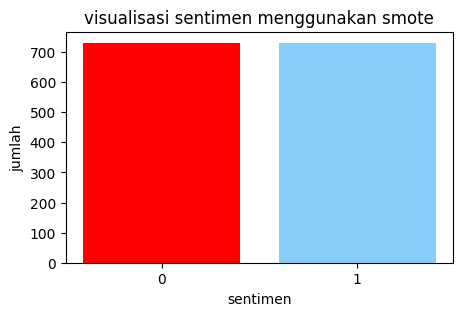

In [170]:
sentimen_counts = y_train_resampled.value_counts()
plt.figure(figsize=(5,3))
plt.bar(sentimen_counts.index,sentimen_counts.values,color=["red","lightskyblue"])
plt.xlabel("sentimen")
plt.ylabel("jumlah")
plt.title("visualisasi sentimen menggunakan smote")
plt.xticks(sentimen_counts.index,["0","1"])
plt.show()

## 5. Modelling


In [171]:
naive_bayes=MultinomialNB()
naive_bayes.fit(x_train_resampled,y_train_resampled )

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [172]:
y_pred=naive_bayes.predict(x_test_vec)


In [175]:
print(y_test)

473     0
643     0
328     0
205     0
274     1
       ..
1401    0
378     0
261     0
1499    0
1258    1
Name: sentimen, Length: 206, dtype: object


## 5. Evaluasi Model

In [176]:
y_test=y_test.astype(int)
accuracy=accuracy_score(y_test,y_pred)
clasification_rep=classification_report(y_test,y_pred,target_names=["negatif","positif"])

print("akurasi model naive bayes: ",accuracy)
print("Laporan klasifikasi: ",clasification_rep)

akurasi model naive bayes:  0.7961165048543689
Laporan klasifikasi:                precision    recall  f1-score   support

     negatif       0.81      0.90      0.85       137
     positif       0.75      0.59      0.66        69

    accuracy                           0.80       206
   macro avg       0.78      0.75      0.76       206
weighted avg       0.79      0.80      0.79       206



In [189]:
## testing
new_text=input("masukan teks: ")
new_text_vec = vectorizer.transform([new_text])
prediction_sentimen = naive_bayes.predict(new_text_vec)

if prediction_sentimen[0]==1:
  sentiment_label="positif"
elif prediction_sentimen[0]==0:
  sentiment_label="negatif"
  
print ("hasil analisis: ", sentiment_label)

hasil analisis:  positif
